# Spider Role-SQL Dev/Test Generation Notebook

This notebook provides an interpretable end-to-end workflow for generating role assignments and Role-SQL datasets for Spider dev and test splits, with logging, statistics, and visualization at each stage.

## 0. Notebook Overview

- ✅ Automatically discovers project directory and prepares logging environment
- ✅ Custom or deterministic role generation (works without API keys)
- ✅ Batch processing for dev/test splits with sampling and parallel support
- ✅ Summary display, statistical tables, and optional word cloud visualization
- ✅ Output artifact paths and reproducible command logs

## 1. Environment and Dependency Check

Prepare paths, logging, dependencies, and import core modules.

In [1]:
import json
import logging
import os
import re
import sys
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import pandas as pd

try:
    import matplotlib.pyplot as plt  # type: ignore
except ImportError:
    plt = None

try:
    from wordcloud import WordCloud
except ImportError:
    WordCloud = None

NOTEBOOK_RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
logger = logging.getLogger("spider_notebook")
if not logger.handlers:
    stream_handler = logging.StreamHandler(sys.stdout)
    stream_handler.setFormatter(logging.Formatter("[%(levelname)s] %(message)s"))
    logger.addHandler(stream_handler)
logger.setLevel(logging.INFO)

# --- project path discovery ---
project_root = Path.cwd().resolve()
if not (project_root / "requirements.txt").exists():
    for candidate in project_root.parents:
        if (candidate / "requirements.txt").exists():
            project_root = candidate
            break
if not (project_root / "requirements.txt").exists():
    raise RuntimeError("Could not locate a project root containing requirements.txt. Check the working directory.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.processors.spider_role_processor import SpiderDataProcessor, SpiderRoleProcessor
from src.processors.spider_role_sql_generator import RoleSQLGenerator
from src.role_parser.generator import ParallelRoleGenerator

outputs_dir = project_root / "outputs"
logs_dir = project_root / "logs"
outputs_dir.mkdir(parents=True, exist_ok=True)
logs_dir.mkdir(parents=True, exist_ok=True)

spider_root = project_root / "data" / "spider"
spider_outputs_dir = outputs_dir / "spider_data"
spider_outputs_dir.mkdir(parents=True, exist_ok=True)

notebook_log_path = logs_dir / f"spider_role_generation_{NOTEBOOK_RUN_ID}.log"
if not any(isinstance(handler, logging.FileHandler) and getattr(handler, "baseFilename", "") == str(notebook_log_path) for handler in logger.handlers):
    file_handler = logging.FileHandler(notebook_log_path, mode="w", encoding="utf-8")
    file_handler.setLevel(logging.DEBUG)
    file_formatter = logging.Formatter("[%(asctime)s] %(levelname)s %(name)s: %(message)s")
    file_handler.setFormatter(file_formatter)
    logger.addHandler(file_handler)
logger.info("Notebook run log will be written to %s", notebook_log_path)

# --- critical resource paths ---
spider_resources = {
    "project_root": project_root,
    "spider_root": spider_root,
    "spider_database_dir": spider_root / "database",
    "spider_test_database_dir": spider_root / "test_database",
    "spider_tables_file": spider_root / "tables.json",
    "spider_dev_file": spider_root / "dev.json",
    "spider_test_file": spider_root / "test.json",
}

resource_rows = []
for name, path in spider_resources.items():
    exists = path.exists()
    resource_rows.append(
        {
            "Resource": name,
            "Exists": exists,
            "Path": str(path),
        }
    )
resource_df = pd.DataFrame(resource_rows)
display(resource_df)
missing_resources = resource_df.loc[~resource_df["Exists"], "Resource"].tolist()
if missing_resources:
    logger.warning("Missing resources: %s", missing_resources)
else:
    logger.info("All core Spider resources detected successfully.")

[INFO] Notebook run log will be written to /home/feiy/Role-SQL-benchmark/logs/spider_role_generation_20251005_144336.log


/home/feiy/anaconda3/envs/llm4db/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Resource,Exists,Path
0,project_root,True,/home/feiy/Role-SQL-benchmark
1,spider_root,True,/home/feiy/Role-SQL-benchmark/data/spider
2,spider_database_dir,True,/home/feiy/Role-SQL-benchmark/data/spider/data...
3,spider_test_database_dir,True,/home/feiy/Role-SQL-benchmark/data/spider/test...
4,spider_tables_file,True,/home/feiy/Role-SQL-benchmark/data/spider/tabl...
5,spider_dev_file,True,/home/feiy/Role-SQL-benchmark/data/spider/dev....
6,spider_test_file,True,/home/feiy/Role-SQL-benchmark/data/spider/test...


[INFO] All core Spider resources detected successfully.


## 2. Role Generation Utility Functions

Helper functions for parsing schemas, building roles, and detecting API credentials.

## 2. Role Generation Helper Functions (Continued)

Data structures for locating artifacts, parsing schemas, building deterministic roles, and split configurations.

In [2]:
TABLE_PATTERN = re.compile(r"CREATE\s+TABLE\s+(?:IF\s+NOT\s+EXISTS\s+)?[`\"\[]?([A-Za-z0-9_]+)[`\"\]]?", re.IGNORECASE)
DEFAULT_BATCH_SIZE = 8

@dataclass(frozen=True)
class SplitConfig:
    name: str
    label: str
    source_file: Path
    database_dir: Path
    role_patterns: Sequence[str]
    dataset_patterns: Sequence[str]
    baseline_patterns: Sequence[str] = tuple()


def locate_latest(patterns: Sequence[str], search_dirs: Iterable[Path], preferred_substring: Optional[str] = None) -> Optional[Path]:
    candidates: List[Path] = []
    for directory in search_dirs:
        if not directory.exists():
            continue
        for pattern in patterns:
            candidates.extend(directory.glob(pattern))
    if not candidates:
        return None
    if preferred_substring:
        preferred_candidates = [path for path in candidates if preferred_substring in path.stem]
        if preferred_candidates:
            candidates = preferred_candidates
    return max(candidates, key=lambda path: path.stat().st_mtime)


def extract_run_timestamp(artifact_path: Path) -> Optional[str]:
    parts = artifact_path.stem.split("_")
    if len(parts) < 2:
        return None
    tail = parts[-2:]
    if all(segment.isdigit() for segment in tail):
        return "_".join(tail)
    return None


def locate_artifact_with_timestamp(
    patterns: Sequence[str],
    search_dirs: Iterable[Path],
    timestamp: str,
    preferred_substring: Optional[str] = None,
 ) -> Optional[Path]:
    if not timestamp:
        return None
    for directory in search_dirs:
        if not directory.exists():
            continue
        candidates: List[Path] = []
        for pattern in patterns:
            candidates.extend(directory.glob(pattern))
        for candidate in sorted(candidates, key=lambda path: path.stat().st_mtime, reverse=True):
            if extract_run_timestamp(candidate) == timestamp:
                if preferred_substring and preferred_substring not in candidate.stem:
                    continue
                return candidate
    return None


def gather_database_names(records: Sequence[Dict[str, str]]) -> List[str]:
    db_names = {item.get("db_id") for item in records if item.get("db_id")
    }
    return sorted(db_name for db_name in db_names if db_name)


def validate_database_dirs(db_root: Path, db_names: Sequence[str]) -> Tuple[List[Path], List[str]]:
    valid_dirs: List[Path] = []
    skipped: List[str] = []
    for name in db_names:
        db_path = db_root / name
        schema_file = db_path / "schema.sql"
        sqlite_files = list(db_path.glob("*.sqlite"))
        if not schema_file.exists() or not sqlite_files:
            skipped.append(name)
            continue
        valid_dirs.append(db_path)
    return valid_dirs, skipped


def parse_tables_from_schema(schema_path: Path) -> List[str]:
    try:
        schema_text = schema_path.read_text(encoding="utf-8")
    except FileNotFoundError:
        return []
    tables = {match.group(1).strip('`"[]').lower() for match in TABLE_PATTERN.finditer(schema_text)}
    return sorted(table for table in tables if table)


def build_deterministic_roles(table_names: Sequence[str]) -> List[Dict[str, str]]:
    table_list = [table_name for table_name in table_names if table_name]
    if not table_list:
        return []
    all_tables = ", ".join(table_list)
    roles: List[Dict[str, str]] = [
        {
            "role": "SystemManager",
            "description": "Full access to all tables for administration and auditing.",
            "tables": all_tables,
        }
    ]
    if len(table_list) > 1:
        midpoint = max(1, len(table_list) // 2)
        limited_tables = ", ".join(table_list[:midpoint])
        roles.append(
            {
                "role": "DataAnalyst",
                "description": "Read access to a limited subset of tables for analysis tasks.",
                "tables": limited_tables,
            }
        )
        remaining_tables = ", ".join(table_list[midpoint:])
        if remaining_tables and remaining_tables != limited_tables:
            roles.append(
                {
                    "role": "OperationsAuditor",
                    "description": "Focuses on operational tables for compliance review.",
                    "tables": remaining_tables,
                }
            )
    else:
        roles.append(
            {
                "role": "ReadOnlyAnalyst",
                "description": "Limited read-only access mirroring the primary role.",
                "tables": all_tables,
            }
        )
    return roles


def generate_deterministic_assignments(valid_dirs: Sequence[Path]) -> Dict[str, List[Dict[str, str]]]:
    assignments: Dict[str, List[Dict[str, str]]] = {}
    for db_path in valid_dirs:
        tables = parse_tables_from_schema(db_path / "schema.sql")
        if not tables:
            logger.warning("Skipping %s: schema could not be parsed.", db_path.name)
            continue
        roles = build_deterministic_roles(tables)
        if roles:
            assignments[db_path.name] = roles
    return assignments


def detect_api_credentials() -> Tuple[Optional[str], Optional[str]]:
    env_candidates = [
        "SPIDER_ROLE_API_KEY",
        "DEEPSEEK_API_KEY",
        "OPENAI_API_KEY",
        "AZURE_OPENAI_API_KEY",
        "ANTHROPIC_API_KEY",
    ]
    for env_name in env_candidates:
        value = os.environ.get(env_name)
        if value:
            return value, env_name
    return None, None


def instantiate_role_generator(model: str, api_key: str, workers: int) -> ParallelRoleGenerator:
    logger.info("Detected API credentials; initializing model %s with %s workers.", model, workers)
    return ParallelRoleGenerator(model=model, api_key=api_key, n_workers=workers)


split_configs: Dict[str, SplitConfig] = {
    "dev": SplitConfig(
        name="dev",
        label="spider_dev",
        source_file=spider_root / "dev.json",
        database_dir=spider_root / "database",
        role_patterns=("role_assignments_spider_dev_*.json", "role_assignments_spider_*.json", "role_assignments_*_dev.json"),
        dataset_patterns=("role_sql_dataset_spider_dev_*.json", "role_sql_dataset_spider_*.json", "role_sql_dataset_*_dev.json"),
        baseline_patterns=("baseline_dataset_spider_dev_*.json", "baseline_dataset_spider_*.json", "baseline_dataset_*_dev.json"),
    ),
    "test": SplitConfig(
        name="test",
        label="spider_test",
        source_file=spider_root / "test.json",
        database_dir=spider_root / "test_database",
        role_patterns=("role_assignments_spider_test_*.json", "role_assignments_spider_*.json", "role_assignments_*_test.json"),
        dataset_patterns=("role_sql_dataset_spider_test_*.json", "role_sql_dataset_spider_*.json", "role_sql_dataset_*_test.json"),
        baseline_patterns=("baseline_dataset_spider_test_*.json", "baseline_dataset_spider_*.json", "baseline_dataset_*_test.json"),
    ),
}

## 3. Run Configuration

Select the Spider split to process, optional sampling limits, and parallel configuration.

In [3]:
RUN_SPLITS = ["dev", "test"]  # Options: ['dev', 'test']
SAMPLE_LIMIT: Optional[int] = None  # Limit to the first N databases for debugging
OVERRIDE_BATCH_SIZE: Optional[int] = None  # Custom batch size when invoking the API generator
FORCE_REGENERATE = False  # Force LLM regeneration even if cached files exist
MODEL_NAME = os.environ.get("SPIDER_ROLE_MODEL", "deepseek-chat")
DEFAULT_WORKERS = int(os.environ.get("SPIDER_ROLE_WORKERS", "8"))
WORKERS = DEFAULT_WORKERS

## 4. Core Processing Functions

Encapsulates role generation and Role-SQL dataset construction logic for a single Spider split. Automatically handles deterministic mode without API keys and simultaneously exports baseline datasets without roles.
- Role dataset entries include `gold_sql` and `difficulty` metadata for subsequent evaluation.
- Baseline dataset retains unique (db, question, gold_sql) combinations, directly usable as a control set.

In [4]:
def process_split(
    split: str,
    config: SplitConfig,
    *,
    data_processor: SpiderDataProcessor,
    role_sql_generator: RoleSQLGenerator,
    generator: Optional[ParallelRoleGenerator],
    outputs_dir: Path,
    sample_limit: Optional[int] = None,
    batch_size: Optional[int] = None,
    force_regenerate: bool = False,
 ) -> Dict[str, object]:
    logger.info("\n===== Processing Spider split: %s =====", split)
    if not config.source_file.exists():
        raise FileNotFoundError(f"Spider source file not found: {config.source_file}")

    spider_data = data_processor.load_raw_split(split, require_query=True)
    db_names = gather_database_names(spider_data)
    logger.info("Loaded %s records spanning %s databases.", len(spider_data), len(db_names))

    if sample_limit is not None and sample_limit > 0:
        db_names = db_names[:sample_limit]
        logger.info("Sample mode enabled: processing the first %s databases only.", len(db_names))

    outputs_dir.mkdir(parents=True, exist_ok=True)

    valid_dirs, skipped_due_to_schema = validate_database_dirs(config.database_dir, db_names)
    if not valid_dirs:
        raise RuntimeError(f"No databases with both schema.sql and sqlite files available for split {split}.")
    if sample_limit is not None and sample_limit > 0:
        valid_dirs = valid_dirs[:sample_limit]
    logger.info(
        "Databases with required artefacts: %s; skipped due to missing schema/sqlite: %s.",
        len(valid_dirs),
        len(skipped_due_to_schema),
    )
    if skipped_due_to_schema:
        logger.debug("Skipped databases: %s", ", ".join(skipped_due_to_schema))

    reuse_allowed = not force_regenerate and (sample_limit is None or sample_limit <= 0)
    search_dirs: Tuple[Path, ...] = (outputs_dir,)
    timestamp_label = datetime.now().strftime("%Y%m%d_%H%M%S")
    role_assignments_path: Optional[Path] = None
    assignment_db_ids: List[str] = []
    new_generation = False
    dataset_path: Optional[Path] = None
    baseline_path: Optional[Path] = None
    cached_role_path: Optional[Path] = None

    def baseline_has_required_metadata(entries: List[Dict[str, Any]]) -> bool:
        if not entries:
            return False
        required_fields = ("db_id", "instruction", "input", "output", "gold_sql", "difficulty")
        for entry in entries:
            if not isinstance(entry, dict):
                continue
            for field in required_fields:
                if field not in entry:
                    return False
            if not entry.get("gold_sql") or not entry.get("difficulty"):
                return False
        return True

    def load_assignment_ids(path: Path) -> List[str]:
        try:
            with path.open("r", encoding="utf-8") as f:
                payload = json.load(f)
            return list(payload.get("assignments", {}).keys())
        except Exception as exc:
            logger.warning("Failed to load assignment metadata from %s: %s", path, exc)
            return []

    if reuse_allowed:
        cached_role_path = locate_latest(
            config.role_patterns,
            search_dirs,
            preferred_substring=config.label,
        )
        if cached_role_path:
            try:
                with cached_role_path.open("r", encoding="utf-8") as f:
                    cached_payload = json.load(f)
                cached_assignments = cached_payload.get("assignments", {})
                metadata = cached_payload.get("metadata") or {}
                dataset_type = metadata.get("dataset_type")
                if dataset_type and dataset_type != config.label:
                    logger.info(
                        "Cached role assignments %s target dataset_type %s (expected %s); ignoring reuse.",
                        cached_role_path,
                        dataset_type,
                        config.label,
                    )
                    cached_role_path = None
                elif cached_assignments:
                    role_assignments_path = cached_role_path
                    assignment_db_ids = list(cached_assignments.keys())
                    cached_timestamp = extract_run_timestamp(cached_role_path)
                    if cached_timestamp:
                        timestamp_label = cached_timestamp
                        dataset_path = locate_artifact_with_timestamp(
                            config.dataset_patterns,
                            search_dirs,
                            cached_timestamp,
                            preferred_substring=config.label,
                        )
                        if config.baseline_patterns:
                            baseline_path = locate_artifact_with_timestamp(
                                config.baseline_patterns,
                                search_dirs,
                                cached_timestamp,
                                preferred_substring=config.label,
                            )
                    logger.info(
                        "Reusing cached role assignments from %s (set FORCE_REGENERATE=True to override).",
                        cached_role_path,
                    )
                    if config.label not in cached_role_path.stem:
                        logger.debug(
                            "Reused role assignments %s without label in filename; dataset_type=%s.",
                            cached_role_path,
                            dataset_type or "<missing>",
                        )
                else:
                    logger.warning(
                        "Cached role assignment file %s contained no assignments; ignoring reuse.",
                        cached_role_path,
                    )
                    cached_role_path = None
            except Exception as exc:
                logger.warning(
                    "Failed to reuse cached role assignments from %s: %s",
                    cached_role_path,
                    exc,
                )
                cached_role_path = None

    if role_assignments_path is None:
        if generator is None:
            logger.warning("API credentials not detected; falling back to deterministic role generation.")
            deterministic_assignments = generate_deterministic_assignments(valid_dirs)
            if not deterministic_assignments:
                raise RuntimeError(f"Deterministic role generation failed for split {split}. Check schema files.")
            payload = {
                "assignments": deterministic_assignments,
                "metadata": {
                    "timestamp": timestamp_label,
                    "total_databases": len(db_names),
                    "processed_databases": len(deterministic_assignments),
                    "total_roles_generated": sum(len(value) for value in deterministic_assignments.values()),
                    "batch_size": 0,
                    "dataset_type": config.label,
                    "generation_mode": "deterministic",
                },
            }
            role_processor = SpiderRoleProcessor(generator=None, database_dir=config.database_dir, dataset_label=config.label)
            role_assignments_path = role_processor.save_role_assignments(payload, outputs_dir, filename_suffix=timestamp_label)
            assignment_db_ids = list(deterministic_assignments.keys())
            new_generation = True
            logger.info("Deterministic role file saved to %s", role_assignments_path)
        else:
            role_processor = SpiderRoleProcessor(generator=generator, database_dir=config.database_dir, dataset_label=config.label)
            selected_names = [path.name for path in valid_dirs]
            role_results = role_processor.process_databases(
                selected_names,
                batch_size=batch_size or min(len(selected_names), DEFAULT_BATCH_SIZE),
                run_timestamp=timestamp_label,
            )
            role_assignments_path = role_processor.save_role_assignments(role_results, outputs_dir, filename_suffix=timestamp_label)
            assignment_db_ids = list(role_results.get("assignments", {}).keys())
            new_generation = True
            logger.info("Role generation via API completed; results stored at %s", role_assignments_path)

    if role_assignments_path is None:
        raise RuntimeError(f"Could not resolve the role assignment path for split {split}.")

    if dataset_path and config.label not in dataset_path.stem:
        logger.info(
            "Discarding dataset cache %s because filename is not aligned with split label %s.",
            dataset_path,
            config.label,
        )
        dataset_path = None
    if baseline_path and config.label not in baseline_path.stem:
        logger.info(
            "Discarding baseline cache %s because filename is not aligned with split label %s.",
            baseline_path,
            config.label,
        )
        baseline_path = None

    dataset_needs_save = False
    if dataset_path and dataset_path.exists() and reuse_allowed:
        with dataset_path.open("r", encoding="utf-8") as f:
            dataset: List[Dict[str, Any]] = json.load(f)  # type: ignore[var-annotated]
        logger.info("Reusing Role-SQL dataset from %s", dataset_path)
        if not dataset:
            logger.warning("Cached Role-SQL dataset %s was empty; regenerating from assignments.", dataset_path)
            dataset = role_sql_generator.generate_role_sql_dataset(
                role_file_path=str(role_assignments_path),
                data_source=split,
                spider_data=spider_data,
            )
            dataset_needs_save = True
            if dataset_path is None:
                dataset_path = outputs_dir / f"role_sql_dataset_{config.label}_{timestamp_label}.json"
    else:
        dataset = role_sql_generator.generate_role_sql_dataset(
            role_file_path=str(role_assignments_path),
            data_source=split,
            spider_data=spider_data,
        )
        dataset_needs_save = True
        if dataset_path is None:
            dataset_path = outputs_dir / f"role_sql_dataset_{config.label}_{timestamp_label}.json"

    def ensure_role_dataset(current_dataset: List[Dict[str, Any]], current_role_path: Path) -> Tuple[List[Dict[str, Any]], bool]:
        nonlocal assignment_db_ids, role_assignments_path, dataset_path, new_generation
        if current_dataset:
            return current_dataset, False

        logger.warning("Role-SQL dataset for split %s was empty when using %s; attempting fallbacks.", split, current_role_path)

        fallback_paths: List[Path] = []
        if current_role_path:
            fallback_paths.append(current_role_path)
        if cached_role_path and cached_role_path not in fallback_paths:
            fallback_paths.append(cached_role_path)

        for candidate_path in fallback_paths:
            dataset_candidate = role_sql_generator.generate_role_sql_dataset(
                role_file_path=str(candidate_path),
                data_source=split,
                spider_data=spider_data,
            )
            if dataset_candidate:
                if candidate_path != role_assignments_path:
                    assignment_db_ids = load_assignment_ids(candidate_path)
                    role_assignments_path = candidate_path
                if dataset_path is None:
                    dataset_path = outputs_dir / f"role_sql_dataset_{config.label}_{timestamp_label}.json"
                logger.info("Recovered role dataset using assignments from %s", candidate_path)
                return dataset_candidate, True

        deterministic_assignments = generate_deterministic_assignments(valid_dirs)
        if deterministic_assignments:
            logger.info("Falling back to deterministic role assignments for split %s.", split)
            payload = {
                "assignments": deterministic_assignments,
                "metadata": {
                    "timestamp": timestamp_label,
                    "total_databases": len(db_names),
                    "processed_databases": len(deterministic_assignments),
                    "total_roles_generated": sum(len(value) for value in deterministic_assignments.values()),
                    "batch_size": 0,
                    "dataset_type": config.label,
                    "generation_mode": "deterministic-fallback",
                },
            }
            fallback_processor = SpiderRoleProcessor(generator=None, database_dir=config.database_dir, dataset_label=config.label)
            role_assignments_path = fallback_processor.save_role_assignments(payload, outputs_dir, filename_suffix=timestamp_label)
            assignment_db_ids = list(deterministic_assignments.keys())
            new_generation = True
            dataset_candidate = role_sql_generator.generate_role_sql_dataset(
                role_file_path=str(role_assignments_path),
                data_source=split,
                spider_data=spider_data,
            )
            if dataset_candidate:
                if dataset_path is None:
                    dataset_path = outputs_dir / f"role_sql_dataset_{config.label}_{timestamp_label}.json"
                logger.info("Recovered role dataset using deterministic fallback assignments.")
                return dataset_candidate, True

        raise RuntimeError(f"Role-SQL dataset for split {split} is empty after fallback attempts.")

    dataset, fallback_requires_save = ensure_role_dataset(dataset, role_assignments_path)
    dataset_needs_save = dataset_needs_save or fallback_requires_save
    if dataset_needs_save:
        if dataset_path is None:
            dataset_path = outputs_dir / f"role_sql_dataset_{config.label}_{timestamp_label}.json"
        role_sql_generator.save_dataset(dataset, output_path=str(dataset_path))
        logger.info("Role-SQL dataset saved to %s with %s samples.", dataset_path, len(dataset))
    else:
        logger.info("Role-SQL dataset ready with %s samples.", len(dataset))

    sample_entry = next((item for item in dataset if isinstance(item, dict)), None)
    missing_metadata: List[str] = []
    if sample_entry is not None:
        missing_metadata = [field for field in ("gold_sql", "difficulty") if field not in sample_entry]
    elif not dataset:
        missing_metadata = ["gold_sql", "difficulty"]

    if missing_metadata:
        logger.info(
            "Role dataset %s is missing metadata columns %s; regenerating dataset with metadata.",
            dataset_path or "<unsaved>",
            missing_metadata,
        )
        dataset = role_sql_generator.generate_role_sql_dataset(
            role_file_path=str(role_assignments_path),
            data_source=split,
            spider_data=spider_data,
        )
        if not dataset:
            raise RuntimeError(f"Role-SQL dataset for split {split} is empty after regeneration.")
        if dataset_path is None:
            dataset_path = outputs_dir / f"role_sql_dataset_{config.label}_{timestamp_label}.json"
        role_sql_generator.save_dataset(dataset, output_path=str(dataset_path))
        logger.info("Role-SQL dataset saved to %s with metadata columns.", dataset_path)

    allowed_examples = sum(1 for item in dataset if item.get("output") != "Sorry, I cannot answer.")
    total_examples = len(dataset)

    baseline_examples: Optional[int] = None
    baseline_dataset: List[Dict[str, Any]] = []
    if baseline_path and baseline_path.exists() and reuse_allowed:
        with baseline_path.open("r", encoding="utf-8") as f:
            baseline_dataset = json.load(f)
        if not baseline_has_required_metadata(baseline_dataset):
            logger.info("Baseline dataset %s is missing expected metadata; regenerating with metadata.", baseline_path)
            regenerated_baseline = role_sql_generator.generate_baseline_dataset(
                data_source=split,
                spider_data=spider_data,
            )
            if regenerated_baseline:
                baseline_dataset = regenerated_baseline
                role_sql_generator.save_dataset(baseline_dataset, output_path=str(baseline_path))
                logger.info("Baseline dataset regenerated with metadata and saved to %s.", baseline_path)
            else:
                logger.warning("Failed to regenerate baseline dataset with metadata for split %s; using existing cache.", split)
        role_sql_generator._latest_baseline = baseline_dataset
        baseline_examples = len(baseline_dataset)
        logger.info("Reusing baseline dataset from %s", baseline_path)
        role_sql_generator._latest_baseline = baseline_dataset
        baseline_examples = len(baseline_dataset)
        logger.info("Reusing baseline dataset from %s", baseline_path)
    else:
        if role_sql_generator._latest_baseline:
            baseline_dataset = role_sql_generator._latest_baseline
        else:
            baseline_dataset = role_sql_generator.generate_baseline_dataset(
                data_source=split,
                spider_data=spider_data,
            )
        if not baseline_has_required_metadata(baseline_dataset):
            logger.info("Baseline dataset for split %s missing metadata; regenerating with metadata.", split)
            regenerated_baseline = role_sql_generator.generate_baseline_dataset(
                data_source=split,
                spider_data=spider_data,
            )
            if regenerated_baseline:
                baseline_dataset = regenerated_baseline
            else:
                logger.warning("Baseline dataset regeneration for split %s produced no entries; proceeding with existing dataset.", split)
        role_sql_generator._latest_baseline = baseline_dataset
        if baseline_dataset:
            if baseline_path is None:
                baseline_path = outputs_dir / f"baseline_dataset_{config.label}_{timestamp_label}.json"
            role_sql_generator.save_dataset(baseline_dataset, output_path=str(baseline_path))
            baseline_examples = len(baseline_dataset)
            logger.info("Baseline dataset saved to %s with %s samples.", baseline_path, baseline_examples)
        else:
            baseline_path = None

    missing_roles = sorted(set(db_names) - set(assignment_db_ids))
    return {
        "split": split,
        "role_assignments": str(role_assignments_path),
        "role_dataset": str(dataset_path) if dataset_path else "",
        "examples": total_examples,
        "allowed_examples": allowed_examples,
        "baseline_dataset": str(baseline_path) if baseline_path else "",
        "baseline_examples": baseline_examples,
        "skipped_schema": skipped_due_to_schema,
        "missing_roles": missing_roles,
        "new_generation": new_generation,
    }

## 5. Batch Execution

Run the cell below to generate roles and Role-SQL datasets sequentially for selected splits, with summary logs.

### Run Batch Processing

In [5]:
invalid_splits = [split for split in RUN_SPLITS if split not in split_configs]
if invalid_splits:
    raise ValueError(f"Unknown split values: {invalid_splits}. Supported options: {sorted(split_configs.keys())}")

api_key, api_env = detect_api_credentials()
generator: Optional[ParallelRoleGenerator] = None
if api_key:
    logger.info("Detected API credential in environment variable %s.", api_env)
    generator = instantiate_role_generator(MODEL_NAME, api_key, WORKERS)
elif FORCE_REGENERATE:
    raise RuntimeError("FORCE_REGENERATE is True but no API key was detected; cannot invoke the LLM generator.")
else:
    logger.info("No API credentials detected; deterministic role generation will be used.")

data_processor = SpiderDataProcessor(project_root)
role_sql_generator = RoleSQLGenerator(project_root)

split_summaries: List[Dict[str, object]] = []
for split in RUN_SPLITS:
    config = split_configs[split]
    result = process_split(
        split=split,
        config=config,
        data_processor=data_processor,
        role_sql_generator=role_sql_generator,
        generator=generator,
        outputs_dir=spider_outputs_dir,
        sample_limit=SAMPLE_LIMIT,
        batch_size=OVERRIDE_BATCH_SIZE,
        force_regenerate=FORCE_REGENERATE,
    )
    split_summaries.append(result)

summary_rows = []
for item in split_summaries:
    baseline_file_str = (item.get("baseline_dataset") or "").strip()
    baseline_file = baseline_file_str or None
    baseline_examples = item.get("baseline_examples")
    if baseline_examples is None and baseline_file:
        try:
            with Path(baseline_file).open("r", encoding="utf-8") as f:
                baseline_examples = len(json.load(f))
        except Exception as exc:
            logger.warning("Failed to load baseline dataset %s: %s", baseline_file, exc)
            baseline_examples = None

    summary_rows.append(
        {
            "split": item.get("split"),
            "examples": item.get("examples", 0),
            "allowed": item.get("allowed_examples", 0),
            "denied": item.get("examples", 0) - item.get("allowed_examples", 0),
            "baseline_examples": baseline_examples if baseline_examples is not None else 0,
            "skipped_schema": len(item.get("skipped_schema", [])),
            "missing_roles": len(item.get("missing_roles", [])),
            "role_file": item.get("role_assignments", ""),
            "dataset_file": item.get("role_dataset", ""),
            "baseline_file": baseline_file or "",
            "regenerated": "Yes" if item.get("new_generation") else "No (cache)",
        }
    )

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

for item, row in zip(split_summaries, summary_rows):
    logger.info(
        "%s → roles: %s | role-dataset: %s | baseline: %s | samples: %s | allowed: %s | denied: %s",
        row.get("split"),
        row.get("role_file"),
        row.get("dataset_file"),
        row.get("baseline_file"),
        row.get("examples"),
        row.get("allowed"),
        row.get("denied"),
    )

[INFO] Detected API credential in environment variable DEEPSEEK_API_KEY.
[INFO] Detected API credentials; initializing model deepseek-chat with 8 workers.
[INFO] 
===== Processing Spider split: dev =====
[INFO] Loaded 1034 records spanning 20 databases.
[INFO] Databases with required artefacts: 15; skipped due to missing schema/sqlite: 5.
[INFO] Reusing cached role assignments from /home/feiy/Role-SQL-benchmark/outputs/spider_data/role_assignments_spider_dev_20250930_230436.json (set FORCE_REGENERATE=True to override).
[INFO] Reusing Role-SQL dataset from /home/feiy/Role-SQL-benchmark/outputs/spider_data/role_sql_dataset_spider_dev_20250930_230436.json
[INFO] Role-SQL dataset ready with 2544 samples.
[INFO] Reusing baseline dataset from /home/feiy/Role-SQL-benchmark/outputs/spider_data/baseline_dataset_spider_dev_20250930_230436.json
[INFO] Reusing baseline dataset from /home/feiy/Role-SQL-benchmark/outputs/spider_data/baseline_dataset_spider_dev_20250930_230436.json
[INFO] 
===== Proc

,split,examples,allowed,denied,baseline_examples,skipped_schema,missing_roles,role_file,dataset_file,baseline_file,regenerated
0,dev,2544,1623,921,665,5,5,/home/feiy/Role-SQL-benchmark/outputs/spider_d...,/home/feiy/Role-SQL-benchmark/outputs/spider_d...,/home/feiy/Role-SQL-benchmark/outputs/spider_d...,No (cache)
1,test,7389,4607,2782,1839,2,3,/home/feiy/Role-SQL-benchmark/outputs/spider_d...,/home/feiy/Role-SQL-benchmark/outputs/spider_d...,/home/feiy/Role-SQL-benchmark/outputs/spider_d...,No (cache)


[INFO] dev → roles: /home/feiy/Role-SQL-benchmark/outputs/spider_data/role_assignments_spider_dev_20250930_230436.json | role-dataset: /home/feiy/Role-SQL-benchmark/outputs/spider_data/role_sql_dataset_spider_dev_20250930_230436.json | baseline: /home/feiy/Role-SQL-benchmark/outputs/spider_data/baseline_dataset_spider_dev_20250930_230436.json | samples: 2544 | allowed: 1623 | denied: 921
[INFO] test → roles: /home/feiy/Role-SQL-benchmark/outputs/spider_data/role_assignments_spider_test_20250930_230453.json | role-dataset: /home/feiy/Role-SQL-benchmark/outputs/spider_data/role_sql_dataset_spider_test_20250930_230453.json | baseline: /home/feiy/Role-SQL-benchmark/outputs/spider_data/baseline_dataset_spider_test_20250930_230453.json | samples: 7389 | allowed: 4607 | denied: 2782


## 6. Results Analysis and Visualization

Display databases with missing schemas/roles, statistical metrics, and optional word clouds or bar charts.

,split,Allowed,Denied,Total
0,dev,1623,921,2544
1,test,4607,2782,7389


[INFO] Databases missing schema/sqlite files: [{'split': 'dev', 'db_id': 'car_1'}, {'split': 'dev', 'db_id': 'flight_2'}, {'split': 'dev', 'db_id': 'voter_1'}, {'split': 'dev', 'db_id': 'world_1'}, {'split': 'dev', 'db_id': 'wta_1'}, {'split': 'test', 'db_id': 'art_1'}, {'split': 'test', 'db_id': 'bakery_1'}]


,split,db_id
0,dev,car_1
1,dev,flight_2
2,dev,voter_1
3,dev,world_1
4,dev,wta_1
5,test,art_1
6,test,bakery_1


[INFO] Databases without generated roles: [{'split': 'dev', 'db_id': 'car_1'}, {'split': 'dev', 'db_id': 'flight_2'}, {'split': 'dev', 'db_id': 'voter_1'}, {'split': 'dev', 'db_id': 'world_1'}, {'split': 'dev', 'db_id': 'wta_1'}, {'split': 'test', 'db_id': 'aan_1'}, {'split': 'test', 'db_id': 'art_1'}, {'split': 'test', 'db_id': 'bakery_1'}]


,split,db_id
0,dev,car_1
1,dev,flight_2
2,dev,voter_1
3,dev,world_1
4,dev,wta_1
5,test,aan_1
6,test,art_1
7,test,bakery_1


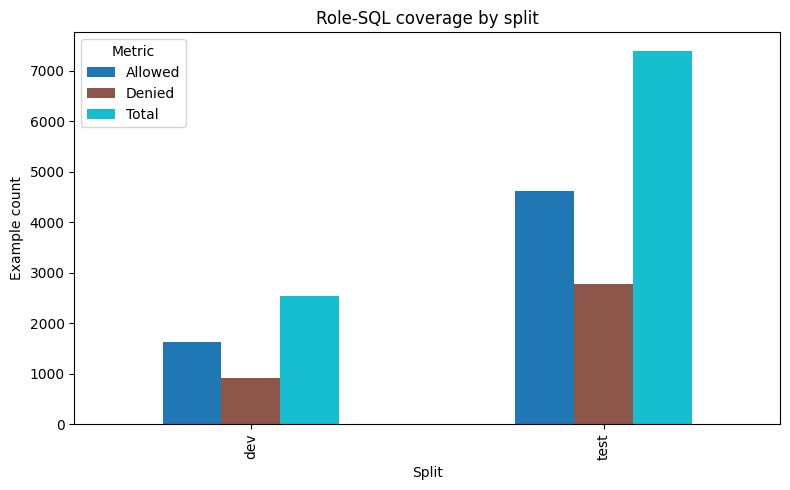

In [6]:
if not split_summaries:
    raise RuntimeError("Run the batch processing cell first to populate split_summaries.")

summary_long_rows = []
missing_schema_rows = []
missing_roles_rows = []
for item in split_summaries:
    split = item["split"]
    summary_long_rows.extend(
        [
            {"split": split, "metric": "Allowed", "value": item["allowed_examples"]},
            {"split": split, "metric": "Denied", "value": item["examples"] - item["allowed_examples"]},
            {"split": split, "metric": "Total", "value": item["examples"]},
        ]
    )
    for db_id in item.get("skipped_schema", []):
        missing_schema_rows.append({"split": split, "db_id": db_id})
    for db_id in item.get("missing_roles", []):
        missing_roles_rows.append({"split": split, "db_id": db_id})

summary_long_df = pd.DataFrame(summary_long_rows)
pivot_df = summary_long_df.pivot(index="split", columns="metric", values="value").reset_index()
pivot_df = pivot_df.rename_axis(None, axis="columns")
display(pivot_df)

if missing_schema_rows:
    logger.info("Databases missing schema/sqlite files: %s", missing_schema_rows)
    display(pd.DataFrame(missing_schema_rows))
else:
    print("All databases include schema and sqlite files.")

if missing_roles_rows:
    logger.info("Databases without generated roles: %s", missing_roles_rows)
    display(pd.DataFrame(missing_roles_rows))
else:
    print("Roles generated for every processed database.")

if plt is not None and not pivot_df.empty:
    metrics_for_plot = [metric for metric in ["Allowed", "Denied", "Total"] if metric in pivot_df.columns]
    ax = (
        pivot_df.set_index("split")[metrics_for_plot]
        .plot(kind="bar", figsize=(8, 5), title="Role-SQL coverage by split", colormap="tab10")
    )
    ax.set_ylabel("Example count")
    ax.set_xlabel("Split")
    ax.legend(title="Metric")
    plt.tight_layout()
    plt.show()
else:
    if plt is None:
        print("matplotlib is not installed; skipping bar chart.")

## 7. Dataset Preview

Extract several records from the latest generated dataset to verify that role constraints are effective.

,db_id,role,tables,input,output,gold_sql,difficulty
0,concert_singer,SystemManager,"stadium, singer, concert, singer_in_concert",How many singers do we have?,SELECT count(*) FROM singer,SELECT count(*) FROM singer,easy
1,concert_singer,EventPlanner,"stadium, concert",How many singers do we have?,"Sorry, I cannot answer.",SELECT count(*) FROM singer,easy
2,concert_singer,TalentCoordinator,"singer, concert, singer_in_concert",How many singers do we have?,SELECT count(*) FROM singer,SELECT count(*) FROM singer,easy
3,concert_singer,VenueManager,stadium,How many singers do we have?,"Sorry, I cannot answer.",SELECT count(*) FROM singer,easy
4,concert_singer,SystemManager,"stadium, singer, concert, singer_in_concert",What is the total number of singers?,SELECT count(*) FROM singer,SELECT count(*) FROM singer,easy
5,concert_singer,EventPlanner,"stadium, concert",What is the total number of singers?,"Sorry, I cannot answer.",SELECT count(*) FROM singer,easy
6,concert_singer,TalentCoordinator,"singer, concert, singer_in_concert",What is the total number of singers?,SELECT count(*) FROM singer,SELECT count(*) FROM singer,easy
7,concert_singer,VenueManager,stadium,What is the total number of singers?,"Sorry, I cannot answer.",SELECT count(*) FROM singer,easy


,role,count
0,SystemManager,665
1,TemplateManager,84
2,DocumentAuthor,84
3,ContentEditor,84
4,BillingSpecialist,82
5,VeterinaryStaff,82
6,FrontDeskCoordinator,82
7,CourseCoordinator,78
8,AcademicRegistrar,78
9,StudentServices,78


,db_id,input,output,gold_sql,difficulty
0,concert_singer,How many singers do we have?,SELECT count(*) FROM singer,SELECT count(*) FROM singer,easy
1,concert_singer,What is the total number of singers?,SELECT count(*) FROM singer,SELECT count(*) FROM singer,easy
2,concert_singer,"Show name, country, age for all singers ordere...","SELECT name , country , age FROM singer ORDE...","SELECT name , country , age FROM singer ORDE...",medium
3,concert_singer,"What are the names, countries, and ages for ev...","SELECT name , country , age FROM singer ORDE...","SELECT name , country , age FROM singer ORDE...",medium
4,concert_singer,"What is the average, minimum, and maximum age ...","SELECT avg(age) , min(age) , max(age) FROM s...","SELECT avg(age) , min(age) , max(age) FROM s...",medium
5,concert_singer,"What is the average, minimum, and maximum age ...","SELECT avg(age) , min(age) , max(age) FROM s...","SELECT avg(age) , min(age) , max(age) FROM s...",medium
6,concert_singer,Show the name and the release year of the song...,"SELECT song_name , song_release_year FROM sin...","SELECT song_name , song_release_year FROM sin...",medium
7,concert_singer,What are the names and release years for all t...,"SELECT song_name , song_release_year FROM sin...","SELECT song_name , song_release_year FROM sin...",medium


[INFO] dev baseline dataset contains 665 examples.


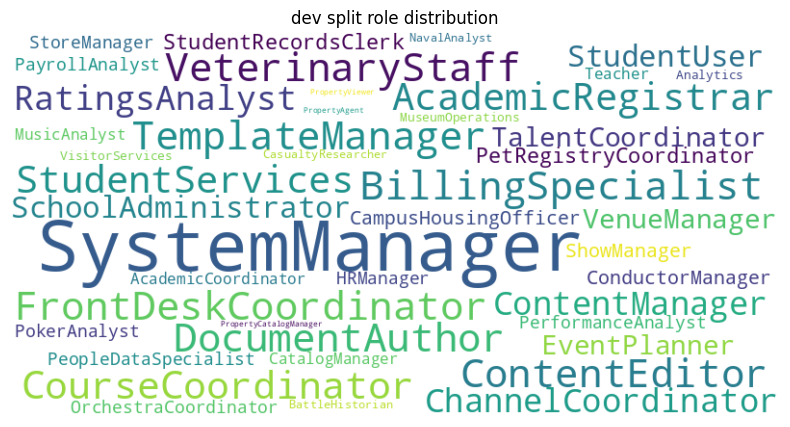

In [7]:
PREVIEW_SPLIT = RUN_SPLITS[0] if RUN_SPLITS else "dev"
preview_entry = next((item for item in split_summaries if item["split"] == PREVIEW_SPLIT), None)
if preview_entry is None:
    raise RuntimeError(f"split_summaries is missing {PREVIEW_SPLIT}; run the batch processing cell first.")

preview_dataset_path = Path(preview_entry["role_dataset"])
if not preview_dataset_path.exists():
    raise FileNotFoundError(f"Dataset path not found: {preview_dataset_path}")

with preview_dataset_path.open("r", encoding="utf-8") as f:
    preview_dataset = json.load(f)

preview_df = pd.DataFrame(preview_dataset[:8])
role_display_columns = [
    col
    for col in ["db_id", "role", "tables", "input", "output", "gold_sql", "difficulty"]
    if col in preview_df.columns
]
if role_display_columns:
    display(preview_df[role_display_columns])
else:
    display(preview_df)
    logger.info(
        "Role preview columns missing expected fields; showing available keys: %s",
        list(preview_df.columns),
    )

role_names = [item.get("role") for item in preview_dataset if item.get("role")]
if role_names:
    role_counts = pd.Series(role_names, name="role").value_counts().reset_index()
    role_counts.columns = ["role", "count"]
    display(role_counts.head(15))

baseline_dataset_path_str = (preview_entry.get("baseline_dataset") or "").strip()
baseline_dataset_path = Path(baseline_dataset_path_str) if baseline_dataset_path_str else None
baseline_example_count = preview_entry.get("baseline_examples")

if baseline_dataset_path and baseline_dataset_path.exists():
    with baseline_dataset_path.open("r", encoding="utf-8") as f:
        baseline_dataset = json.load(f)
    baseline_df = pd.DataFrame(baseline_dataset[:8])
    baseline_display_columns = [
        col
        for col in ["db_id", "input", "output", "gold_sql", "difficulty"]
        if col in baseline_df.columns
    ]
    if baseline_display_columns:
        display(baseline_df[baseline_display_columns])
    else:
        display(baseline_df)
        logger.info(
            "Baseline preview columns missing expected fields; showing available keys: %s",
            list(baseline_df.columns),
        )
elif baseline_dataset_path:
    logger.warning("Baseline dataset recorded but not found on disk: %s", baseline_dataset_path)
else:
    logger.info("No baseline dataset recorded for split %s (cache may not exist yet).", PREVIEW_SPLIT)

if baseline_example_count is not None:
    logger.info("%s baseline dataset contains %s examples.", PREVIEW_SPLIT, baseline_example_count)

if WordCloud is not None and role_names:
    frequency_map = pd.Series(role_names).value_counts().to_dict()
    wc = WordCloud(width=800, height=400, background_color="white")
    wc = wc.generate_from_frequencies(frequency_map)
    if plt is not None:
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"{PREVIEW_SPLIT} split role distribution")
        plt.show()
elif WordCloud is not None:
    print("No role names available for wordcloud rendering.")
else:
    print("wordcloud is not installed; skipping wordcloud display.")

## 8. Notes and Reproducibility

- To rerun the LLM version, set `FORCE_REGENERATE=True` in the run configuration section and provide an API key.
- All artifacts are saved in `outputs/spider_data/`, with filenames containing timestamps for easy comparison across multiple experiments.
- Generation logs are recorded in `logs/spider_role_generation_<timestamp>.log`, useful for tracking which databases were skipped or rejected.